# Irish Property Prices - Modelling

Notebook 4 of 4. Tests whether sale prices can be predicted from publicly available data, and establishes the accuracy ceiling that this data supports.

The headline result is a negative one. Around 61% of price variation occurs within routing keys rather than between them, and the public data contains no property-level features to explain it. Models reach 25.4% median absolute percentage error against a theoretical ceiling of 25.1% - meaning the features available are effectively exhausted, and per-property valuation is not achievable from these sources.

This notebook documents how that conclusion was reached.

In [1]:
# Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RAW = Path("../Data/Raw")
PROCESSED = Path("../Data/Processed")

NAVY, RED, GREEN, AMBER = "#1f4e79", "#c00000", "#4a9e6b", "#e0a030"
BG, GRID = "#fafafa", "#e8e8e8"

def style_axis(ax):
    ax.set_facecolor(BG)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    return ax

def euro(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda v, _: f"€{v:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

In [2]:
# Load cleaned sales 

df = pd.read_parquet(PROCESSED / "ppr_with_ber.parquet")
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")

model_df = df[(df["year"] >= 2021) & df["routing_key"].notna()].copy()

print(f"Full dataset:      {len(df):,}")
print(f"Modelling window:  {len(model_df):,}  ({model_df['date'].min().date()} to {model_df['date'].max().date()})")
print(f"Routing keys:      {model_df['routing_key'].nunique()}")

Full dataset:      750,660
Modelling window:  228,905  (2021-01-01 to 2026-07-31)
Routing keys:      300


## 1. Removing the market trend

Prices rose 8-10% annually across the modelling window, so when a sale happened matters as much as what sold. Rather than including date as a feature and asking the model to learn the trend, all prices are adjusted to a common reference month using the CSO Residential Property Price Index.

This separates two distinct questions - what is this property worth, and what was the market doing - and means predictions are naturally expressed in present-day money.

In [3]:
# CSO Residential Property Price Index 
# used to express all prices in the same money, removing the
# market-wide trend so the model learns property and location
# effects rather than when a sale happened

import requests

CSO_URL = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/HPM09/JSON-stat/2.0/en"

r = requests.get(CSO_URL, timeout=30)
print(f"Status: {r.status_code}")

raw = r.json()
print(f"Label: {raw.get('label')}")
print(f"Dimensions: {list(raw['dimension'].keys())}")
for dim in raw["dimension"]:
    if dim != "id":
        cats = raw["dimension"][dim]["category"]["label"]
        print(f"\n{dim}: {len(cats)} categories")
        print(f"  {list(cats.values())[:8]}")

Status: 200
Label: Residential Property Price Index
Dimensions: ['STATISTIC', 'TLIST(M1)', 'C02803V03373']

STATISTIC: 4 categories
  ['Residential Property Price Index', 'Percentage Change over 1 month for Residential Property Price Index', 'Percentage Change over 3 months for Residential Property Price Index', 'Percentage Change over 12 months for Residential Property Price Index']

TLIST(M1): 258 categories
  ['2005 January', '2005 February', '2005 March', '2005 April', '2005 May', '2005 June', '2005 July', '2005 August']

C02803V03373: 20 categories
  ['National - all residential properties', 'National - houses', 'National - apartments', 'Dublin - all residential properties', 'Dublin - houses', 'Dublin - apartments', 'Dublin City - houses', 'Dun Laoghaire-Rathdown - houses']


In [4]:
# What geographies are available?

geo_dim = raw["dimension"]["C02803V03373"]["category"]["label"]
for code, label in geo_dim.items():
    print(f"  {code}  {label}")

  -  National - all residential properties
  01  National - houses
  02  National - apartments
  05  Dublin - all residential properties
  06  Dublin - houses
  07  Dublin - apartments
  08  Dublin City - houses
  09  Dun Laoghaire-Rathdown - houses
  10  Fingal - houses
  11  South Dublin - houses
  03  National excluding Dublin - all residential properties
  04  National excluding Dublin - houses
  12  National excluding Dublin - apartments
  21  Border - houses
  14  Midland - houses
  15  West - houses
  22  Mid-East - houses
  23  Mid-West - houses
  24  South-East - houses
  19  South-West - houses


In [5]:
# Parse the JSON-stat response 
# JSON-stat stores values as a flat array indexed by the product of
# dimension sizes. The 'index' field may be a dict of code->position
# or a list of codes in position order, so both forms are handled.

def as_position_map(index_field):
    if isinstance(index_field, dict):
        return index_field
    return {code: i for i, code in enumerate(index_field)}

stat_idx = as_position_map(raw["dimension"]["STATISTIC"]["category"]["index"])
time_idx = as_position_map(raw["dimension"]["TLIST(M1)"]["category"]["index"])
geo_idx  = as_position_map(raw["dimension"]["C02803V03373"]["category"]["index"])

values = np.array(
    [np.nan if v is None else v for v in raw["value"]], dtype=float
)
arr = values.reshape(len(stat_idx), len(time_idx), len(geo_idx))

time_labels = raw["dimension"]["TLIST(M1)"]["category"]["label"]
periods = pd.PeriodIndex(
    [pd.Period(time_labels[code].replace(" ", "-"), freq="M")
     for code in sorted(time_idx, key=time_idx.get)],
    freq="M"
)

stat_key = [k for k, v in raw["dimension"]["STATISTIC"]["category"]["label"].items()
            if v == "Residential Property Price Index"][0]
si = stat_idx[stat_key]

def get_series(geo_code, name):
    return pd.Series(arr[si, :, geo_idx[geo_code]], index=periods, name=name).dropna()

rppi = pd.DataFrame({
    "national":  get_series("-",  "national"),
    "dublin":    get_series("05", "dublin"),
    "ex_dublin": get_series("03", "ex_dublin"),
})

print(f"Index: {rppi.index.min()} to {rppi.index.max()}, {len(rppi)} months")
print(rppi.tail(12).round(1).to_string())

Index: 2005-01 to 2026-06, 258 months
         national  dublin  ex_dublin
2025-07     197.7   170.6      226.2
2025-08     199.4   171.8      228.5
2025-09     201.0   173.1      230.4
2025-10     202.2   174.4      231.5
2025-11     203.1   175.2      232.5
2025-12     204.4   175.9      234.3
2026-01     205.2   177.1      234.8
2026-02     204.7   176.3      234.6
2026-03     204.9   176.4      234.9
2026-04     205.0   176.5      235.1
2026-05     205.9   176.7      236.6
2026-06     206.9   177.4      238.1


Index growth across the modelling window:
national     50.1
dublin       41.1
ex_dublin    57.7


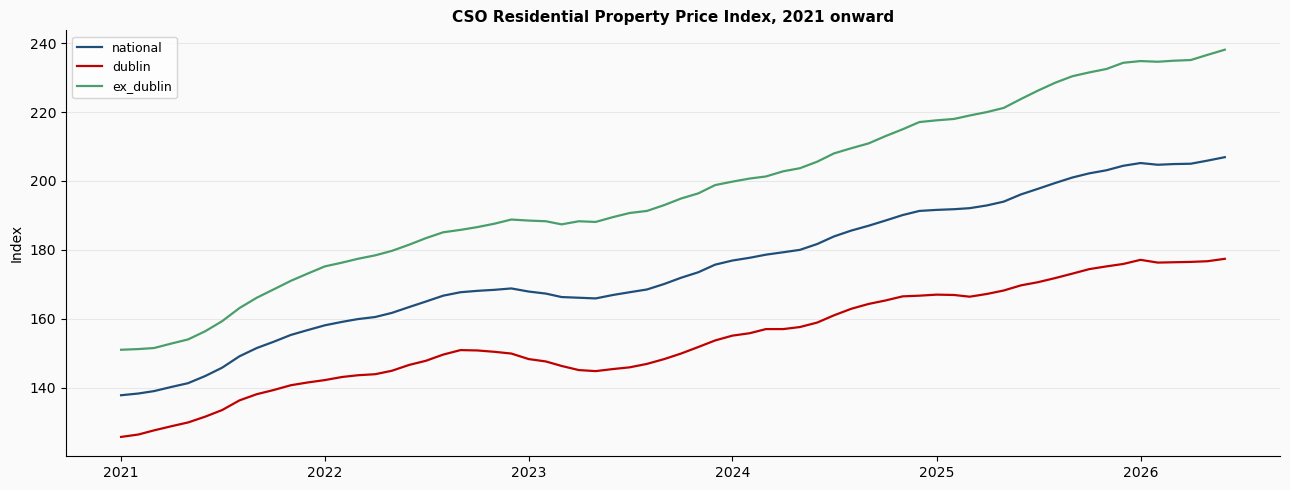

In [6]:
# Do Dublin and the rest need separate adjustment? 

window = rppi[rppi.index >= pd.Period("2021-01", freq="M")]
growth = (window.iloc[-1] / window.iloc[0] - 1) * 100

print("Index growth across the modelling window:")
print(growth.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor(BG)
style_axis(ax)
for col, colour in [("national", NAVY), ("dublin", RED), ("ex_dublin", GREEN)]:
    ax.plot(window.index.to_timestamp(), window[col], color=colour, linewidth=1.6, label=col)
ax.set_ylabel("Index")
ax.set_title("CSO Residential Property Price Index, 2021 onward",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Dublin and the rest of the country have diverged materially. Across the modelling window the ex-Dublin index rose 57.7% against Dublin's 41.1%, a gap of 16.6 percentage points. Using the national series would systematically over-adjust Dublin sales and under-adjust everywhere else, so each region is adjusted on its own series.

The index runs to June 2026 against sales to July 2026. The final month is forward-filled.

In [7]:
# Apply the index 
# Dublin and the rest of the country have diverged materially over
# the window, so each is adjusted on its own series rather than
# the national one.

REFERENCE = pd.Period("2026-06", freq="M")

rppi_full = rppi.reindex(
    pd.period_range(rppi.index.min(), model_df["month"].max(), freq="M")
).ffill()

model_df["index_series"] = np.where(
    model_df["county"] == "Dublin", "dublin", "ex_dublin"
)

idx_lookup = rppi_full.stack().rename("index_value")
idx_lookup.index.names = ["month", "index_series"]

model_df = model_df.merge(
    idx_lookup, left_on=["month", "index_series"], right_index=True, how="left"
)

ref_values = rppi_full.loc[REFERENCE]
model_df["index_ref"] = model_df["index_series"].map(ref_values)

print(f"Unmatched index values: {model_df['index_value'].isna().sum():,}")
print(f"\nReference ({REFERENCE}):")
print(ref_values.round(1).to_string())

Unmatched index values: 0

Reference (2026-06):
national     206.9
dublin       177.4
ex_dublin    238.1


In [8]:
# Adjusted price
# every sale expressed in June 2026 money

model_df["price_adj"] = (
    model_df["price_incl_vat"] * model_df["index_ref"] / model_df["index_value"]
)

check = model_df.groupby("year").agg(
    n=("price_adj", "size"),
    raw_median=("price_incl_vat", "median"),
    adj_median=("price_adj", "median"),
).round(0)
print(check.to_string())

          n  raw_median  adj_median
year                               
2021  29146    268000.0    373666.0
2022  45764    282000.0    360353.0
2023  45409    300000.0    366697.0
2024  43074    327500.0    370005.0
2025  43359    358999.0    374646.0
2026  22153    365000.0    366619.0


In [9]:
check_geo = (model_df.groupby(["year", "index_series"])["price_adj"]
             .median().unstack().round(0))
print(check_geo.to_string())

index_series    dublin  ex_dublin
year                             
2021          505296.0   309221.0
2022          489717.0   308975.0
2023          495783.0   311283.0
2024          500945.0   314382.0
2025          501780.0   317290.0
2026          495000.0   311393.0


The adjustment works as intended. Raw medians span a 36% range across the six years; adjusted medians span 3.9%. Checked separately, Dublin holds €490,000 to €505,000 and ex-Dublin €309,000 to €317,000 across all years, confirming the regional series are each doing their job rather than the aggregate merely averaging out.

The small residual pattern reflects composition effects that the CSO index controls for and raw transaction data does not.

## 2. Features

Eight features are available: the routing key, month of sale, whether the property is a new build, and five area-level BER characteristics.

The target is log-transformed. Property prices are right-skewed, with skew falling from 2.34 to -0.32 under the transform. Modelling log price produces proportional rather than absolute errors, which is appropriate when values span an order of magnitude.

In [10]:
# Feature set 

model_df["month_num"] = model_df["date"].dt.month
model_df["is_new"] = (model_df["property_type"] == "New").astype(int)

FEATURES_CAT = ["routing_key"]
FEATURES_NUM = [
    "month_num",
    "is_new",
    "ber_mean_floor_area",
    "ber_mean_rating",
    "ber_pct_a_or_b",
    "ber_median_year_built",
    "ber_mean_storeys",
]

TARGET = "price_adj"

mdl = model_df[FEATURES_CAT + FEATURES_NUM + [TARGET, "date", "county"]].dropna()

print(f"Modelling rows: {len(mdl):,} of {len(model_df):,}")
print(f"Features: {len(FEATURES_CAT) + len(FEATURES_NUM)}")
print(f"\nTarget summary:")
print(mdl[TARGET].describe().apply(lambda v: f"{v:,.0f}").to_string())

Modelling rows: 228,905 of 228,905
Features: 8

Target summary:
count      228,905
mean       431,682
std        282,167
min         20,000
25%        258,336
50%        368,413
75%        517,974
max      3,044,757


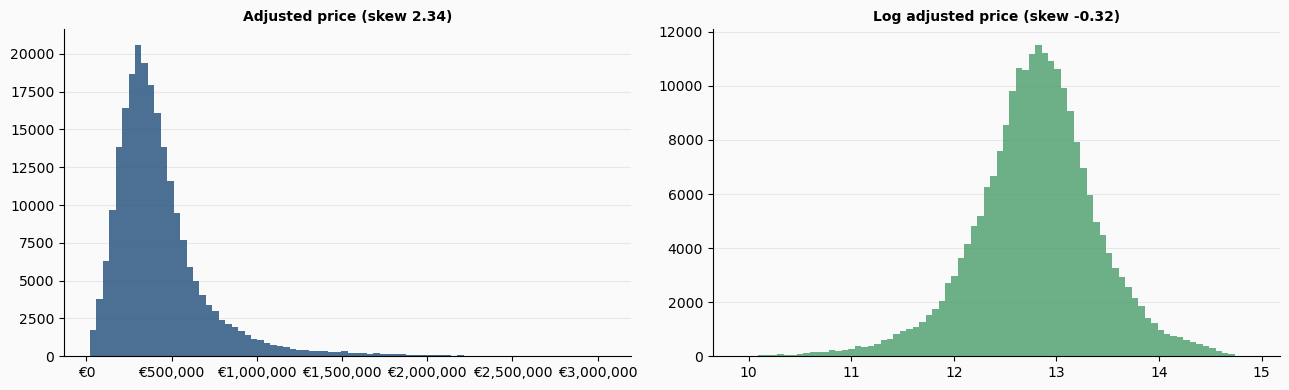

In [11]:
# Log target 
# property prices are right-skewed, so modelling log price gives
# proportional rather than absolute errors and reduces the pull
# of the expensive tail

mdl["log_price"] = np.log(mdl[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor(BG)

ax = style_axis(axes[0])
ax.hist(mdl[TARGET], bins=80, color=NAVY, alpha=0.8)
euro(ax, axis="x")
ax.set_title(f"Adjusted price (skew {mdl[TARGET].skew():.2f})",
             fontsize=10, fontweight="bold")

ax = style_axis(axes[1])
ax.hist(mdl["log_price"], bins=80, color=GREEN, alpha=0.8)
ax.set_title(f"Log adjusted price (skew {mdl['log_price'].skew():.2f})",
             fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 3. Train and test split

The split is temporal rather than random, with the final thirteen months held out. A random split would let the model learn from sales that happened after those it predicts, which is not available in deployment.

32 routing keys appear in the test set but not in training, accounting for 33 sales - 0.07% of the test set. These fall back to the global median.

In [12]:
# Temporal train/test split 
# the test set is the most recent period, mirroring how the model
# would be used in practice

mdl = mdl.sort_values("date").reset_index(drop=True)

SPLIT_DATE = pd.Timestamp("2025-07-01")
train = mdl[mdl["date"] < SPLIT_DATE]
test  = mdl[mdl["date"] >= SPLIT_DATE]

print(f"Train: {len(train):,}  ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {len(test):,}  ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"\nRouting keys in test but not train: "
      f"{len(set(test['routing_key']) - set(train['routing_key']))}")

Train: 182,290  (2021-01-01 to 2025-06-30)
Test:  46,615  (2025-07-01 to 2026-07-31)

Routing keys in test but not train: 32


In [13]:
unseen = set(test["routing_key"]) - set(train["routing_key"])
n_unseen = test["routing_key"].isin(unseen).sum()
print(f"Test rows in unseen routing keys: {n_unseen:,} ({n_unseen/len(test)*100:.2f}%)")

Test rows in unseen routing keys: 33 (0.07%)


## 4. Evaluation approach

Median absolute percentage error is the primary metric. A €50,000 error on a €200,000 property is a very different failure to the same error on a €900,000 one, and absolute metrics such as RMSE obscure that distinction. The proportion of predictions falling within 10% and 20% of the actual price is reported alongside, as these translate more directly into whether a prediction is practically useful.

In [14]:
# Evaluation 
# median absolute percentage error is the primary metric - a
# €50,000 error means something very different on a €200,000
# house than on a €900,000 one

from sklearn.metrics import r2_score

def evaluate(y_true, y_pred, label):
    err = y_pred - y_true
    ape = np.abs(err) / y_true
    res = {
        "model": label,
        "MdAPE": np.median(ape) * 100,
        "MAPE": ape.mean() * 100,
        "within_10pct": (ape <= 0.10).mean() * 100,
        "within_20pct": (ape <= 0.20).mean() * 100,
        "MdAE": np.median(np.abs(err)),
        "RMSE": np.sqrt((err ** 2).mean()),
        "R2": r2_score(y_true, y_pred),
    }
    print(f"{label}")
    print(f"  MdAPE        {res['MdAPE']:.1f}%")
    print(f"  MAPE         {res['MAPE']:.1f}%")
    print(f"  within 10%   {res['within_10pct']:.1f}%")
    print(f"  within 20%   {res['within_20pct']:.1f}%")
    print(f"  median error €{res['MdAE']:,.0f}")
    print(f"  RMSE         €{res['RMSE']:,.0f}")
    print(f"  R2           {res['R2']:.3f}")
    return res

results = []

## 5. Baseline

Predicting each routing key's training median gives 25.6% MdAPE and a median error of €92,496, with 21% of predictions within 10% of the actual price.

This is the bar. Any model must beat it to justify its complexity.

In [15]:
# Baseline: routing key median 
# predicting each area's training median is the obvious naive
# approach and sets the bar any model must clear

rk_median = train.groupby("routing_key")[TARGET].median()
global_median = train[TARGET].median()

pred_baseline = test["routing_key"].map(rk_median).fillna(global_median).values

results.append(evaluate(test[TARGET].values, pred_baseline, "Baseline: routing key median"))

Baseline: routing key median
  MdAPE        25.6%
  MAPE         41.0%
  within 10%   21.2%
  within 20%   40.6%
  median error €92,496
  RMSE         €215,233
  R2           0.341


## 6. Models

Two models were tested. Ridge regression with one-hot encoded routing keys provides an interpretable linear baseline. LightGBM handles the 300 routing keys as a native categorical and can capture interactions a linear model cannot.

| Model | MdAPE | Within 10% | Median error |
| --- | --- | --- | --- |
| Routing key median | 25.6% | 21.2% | €92,496 |
| Ridge | 25.5% | 21.0% | €92,090 |
| LightGBM | 25.4% | 21.3% | €91,185 |

**Neither model meaningfully beats the baseline.** LightGBM's early stopping triggered at iteration 70, indicating it found little worth learning beyond the area effect.

In [16]:
# Model 1: Ridge on one-hot encoded features 
# a linear baseline that is fully interpretable - each routing key
# gets a coefficient that reads directly as a percentage effect
# on price once exponentiated

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=30), FEATURES_CAT),
    ("num", StandardScaler(), FEATURES_NUM),
])

ridge = Pipeline([
    ("pre", pre),
    ("model", Ridge(alpha=1.0)),
])

ridge.fit(train[FEATURES_CAT + FEATURES_NUM], train["log_price"])

pred_ridge = np.exp(ridge.predict(test[FEATURES_CAT + FEATURES_NUM]))
results.append(evaluate(test[TARGET].values, pred_ridge, "Ridge (log target)"))

Ridge (log target)
  MdAPE        25.5%
  MAPE         40.3%
  within 10%   21.0%
  within 20%   40.4%
  median error €92,090
  RMSE         €214,467
  R2           0.346


In [17]:
#!pip install lightgbm

In [18]:
# Model 2: LightGBM 
# gradient boosting handles the categorical routing key natively
# and captures interactions the linear model cannot

import lightgbm as lgb

train_lgb = train.copy()
test_lgb = test.copy()
for d in (train_lgb, test_lgb):
    d["routing_key"] = d["routing_key"].astype("category")

# align categories so the test set uses the training vocabulary
test_lgb["routing_key"] = test_lgb["routing_key"].cat.set_categories(
    train_lgb["routing_key"].cat.categories
)

gbm = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

gbm.fit(
    train_lgb[FEATURES_CAT + FEATURES_NUM],
    train_lgb["log_price"],
    eval_set=[(test_lgb[FEATURES_CAT + FEATURES_NUM], test_lgb["log_price"])],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(100, verbose=False)],
)

print(f"Best iteration: {gbm.best_iteration_}")

pred_gbm = np.exp(gbm.predict(test_lgb[FEATURES_CAT + FEATURES_NUM]))
results.append(evaluate(test[TARGET].values, pred_gbm, "LightGBM (log target)"))

C:\Users\heffo\anaconda3\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Best iteration: 70
LightGBM (log target)
  MdAPE        25.4%
  MAPE         40.2%
  within 10%   21.3%
  within 20%   40.7%
  median error €91,185
  RMSE         €215,094
  R2           0.342


## 7. Why the models add nothing

Examining what information the features actually carry explains the result.

The routing key is fully captured by the baseline. Month of sale contributes little, since the index adjustment already removed most of the temporal signal. Whether a property is a new build is a single binary flag.

The five BER features are area-level aggregates, constant for every sale within an area. A tree splitting on mean floor area is splitting on the routing key by another name. They carry no information the area identifier does not already encode.

The model therefore has one genuinely new feature beyond the baseline.

In [19]:
# What is the model actually using? 

imp = pd.Series(gbm.feature_importances_,
                index=FEATURES_CAT + FEATURES_NUM).sort_values(ascending=False)
print(imp.to_string())

routing_key              1166
month_num                1089
ber_mean_floor_area       570
is_new                    471
ber_mean_rating           315
ber_mean_storeys          279
ber_pct_a_or_b            256
ber_median_year_built     194


In [20]:
# How much variance is within-area rather than between? 
# an upper bound on what any model using only area can achieve

within = train.groupby("routing_key")["log_price"].transform(lambda s: s - s.mean())
total_var = train["log_price"].var()
within_var = within.var()

print(f"Total variance in log price:   {total_var:.4f}")
print(f"Within-routing-key variance:   {within_var:.4f}")
print(f"Explained by area alone:       {(1 - within_var/total_var)*100:.1f}%")
print(f"Unexplainable without property detail: {within_var/total_var*100:.1f}%")

Total variance in log price:   0.3684
Within-routing-key variance:   0.2250
Explained by area alone:       38.9%
Unexplainable without property detail: 61.1%


The variance decomposition quantifies the limit. Of the total variation in log price, 38.9% occurs between routing keys and 61.1% occurs within them. Two properties in the same area differ in price for reasons the data cannot observe - size, condition, bedroom count, garden, aspect, floor level, whether it needs work.

A model with perfect knowledge of every area but nothing about individual properties achieves 25.1% MdAPE on the test set. The best model achieves 25.4%. The gap is 0.3 percentage points.

The feature set is exhausted. Further tuning, more sophisticated models or additional area-level variables cannot materially improve on this, because the missing information is not area-level.

In [21]:
# Theoretical ceiling 
# a model with perfect knowledge of every area but nothing about
# individual properties can do no better than predict each area's
# median. The residual spread within areas is the error floor.

perfect = test["routing_key"].map(test.groupby("routing_key")[TARGET].median())
ape_perfect = (np.abs(perfect - test[TARGET]) / test[TARGET]).dropna()

print(f"Perfect area knowledge, no property detail:")
print(f"  MdAPE {np.median(ape_perfect)*100:.1f}%")
print(f"\nActual best model: 25.4%")

Perfect area knowledge, no property detail:
  MdAPE 25.1%

Actual best model: 25.4%


## 8. Honest uncertainty

If a point estimate cannot be precise, a calibrated range is more useful than a precise-looking number that is frequently wrong. Quantile regression at the 10th, 50th and 90th percentiles produces prediction intervals rather than point estimates.

In [22]:
# Prediction intervals via quantile regression
# if a point estimate cannot be precise, an honest range is more
# useful than a false single number

quantiles = {}
for q in [0.1, 0.5, 0.9]:
    m = lgb.LGBMRegressor(
        objective="quantile", alpha=q,
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=30, random_state=42, verbose=-1,
    )
    m.fit(train_lgb[FEATURES_CAT + FEATURES_NUM], train_lgb["log_price"])
    quantiles[q] = np.exp(m.predict(test_lgb[FEATURES_CAT + FEATURES_NUM]))

lo, mid, hi = quantiles[0.1], quantiles[0.5], quantiles[0.9]
covered = ((test[TARGET] >= lo) & (test[TARGET] <= hi)).mean()

print(f"80% interval coverage: {covered*100:.1f}%  (target 80%)")
print(f"Median interval width: €{np.median(hi - lo):,.0f}")
print(f"As % of prediction:    {np.median((hi - lo) / mid)*100:.0f}%")

80% interval coverage: 80.3%  (target 80%)
Median interval width: €379,162
As % of prediction:    113%


The intervals are well calibrated, with 80.3% of actual prices falling inside the nominal 80% band. But the median interval width is 113% of the prediction - a property estimated at €350,000 carries a range of roughly €180,000 to €560,000.

This is statistically honest and practically unusable as a valuation. It is, however, an accurate representation of what the data supports, and it makes the limitation visible rather than hiding it behind a single number.

## 9. Conclusion
The finding

Irish public property data supports area-level price analysis to roughly 25% accuracy, and does not support per-property valuation.

The constraint is not technical. The Property Price Register records actual sale prices with addresses; the SEAI BER register records property characteristics. Joining them at property level would produce the features needed. That join is blocked because a BER assessment includes the property address and MPRN, making it personal data under GDPR, and the public research extract removes both. The SA_Code field which would have given Small Area geography is present in the schema but entirely null.

This is a privacy constraint working as intended, not a data quality problem.

What the data does support
Price trends over time, nationally and by area, from 2010 to present
Geographic comparison at routing key level, where variation reaches 2.34 to 1 within Dublin alone
New build premium analysis, at a genuine 25% within comparable areas
Seasonality in both volume and price
Price per square metre at area level, ranging 5.3 to 1 from Dublin 6 to Donegal
Implications for the tool

The accompanying application is scoped accordingly. It reports area-level market statistics and trends rather than presenting itself as a valuation tool. Where a price estimate is shown it is presented as a calibrated range with its width made explicit.

What would change this

A property-level join between sale prices and dwelling characteristics. The full BER data file contains exactly what is needed but is restricted under S.I. No. 243/2012 to the assessor, a subsequent assessor, or the building owner. Commercial address databases licensed from Eircode would permit geocoding but at prohibitive cost for 750,000 records.

In [24]:
# Pre-compute app data 
# the app loads small aggregated files rather than the full
# dataset - Streamlit Cloud is memory constrained and 750k rows
# with free-text addresses will not fit comfortably

APP_DATA = Path("../app/data")
APP_DATA.mkdir(parents=True, exist_ok=True)

full = pd.read_parquet(PROCESSED / "ppr_with_ber.parquet")
full["date"] = pd.to_datetime(full["date"])
full["month"] = full["date"].dt.to_period("M")

eircode_era = full[(full["year"] >= 2021) & full["routing_key"].notna()].copy()

print(f"Full: {len(full):,}  Eircode era: {len(eircode_era):,}")

Full: 750,660  Eircode era: 228,905


In [25]:
# 1. Area monthly series

area_monthly = (eircode_era.groupby(["routing_key", "month"])
                .agg(n=("price_incl_vat", "size"),
                     median=("price_incl_vat", "median"),
                     p25=("price_incl_vat", lambda s: s.quantile(0.25)),
                     p75=("price_incl_vat", lambda s: s.quantile(0.75)))
                .reset_index())
area_monthly["month"] = area_monthly["month"].dt.to_timestamp()

# quarterly is less noisy for small areas
eircode_era["quarter"] = eircode_era["date"].dt.to_period("Q")
area_quarterly = (eircode_era.groupby(["routing_key", "quarter"])
                  .agg(n=("price_incl_vat", "size"),
                       median=("price_incl_vat", "median"))
                  .reset_index())
area_quarterly["quarter"] = area_quarterly["quarter"].dt.to_timestamp()

area_monthly.to_parquet(APP_DATA / "area_monthly.parquet", index=False)
area_quarterly.to_parquet(APP_DATA / "area_quarterly.parquet", index=False)
print(f"area_monthly: {len(area_monthly):,} rows")
print(f"area_quarterly: {len(area_quarterly):,} rows")

area_monthly: 9,086 rows
area_quarterly: 3,360 rows


In [26]:
# 2. Area summary
# one row per routing key with everything the explorer page needs

recent = eircode_era[eircode_era["year"] >= 2024]

summary = (recent.groupby("routing_key")
           .agg(county=("rk_county", "first"),
                n_sales=("price_incl_vat", "size"),
                median=("price_incl_vat", "median"),
                p10=("price_incl_vat", lambda s: s.quantile(0.10)),
                p25=("price_incl_vat", lambda s: s.quantile(0.25)),
                p75=("price_incl_vat", lambda s: s.quantile(0.75)),
                p90=("price_incl_vat", lambda s: s.quantile(0.90)),
                floor_area=("ber_mean_floor_area", "first"),
                ber_rating=("ber_mean_rating", "first"),
                pct_ab=("ber_pct_a_or_b", "first"),
                year_built=("ber_median_year_built", "first"))
           .reset_index())

summary["price_per_sqm"] = (summary["median"] / summary["floor_area"]).round(0)

# new build share and premium where both types have volume
counts = recent.groupby(["routing_key", "property_type"]).size().unstack(fill_value=0)
meds = recent.groupby(["routing_key", "property_type"])["price_incl_vat"].median().unstack()

summary = summary.merge(
    counts.rename(columns={"New": "n_new", "Second-Hand": "n_secondhand"}),
    on="routing_key", how="left"
)
summary["new_share"] = (summary["n_new"] /
                        (summary["n_new"] + summary["n_secondhand"])).round(3)

prem = ((meds["New"] / meds["Second-Hand"] - 1) * 100).round(1)
prem[(counts["New"] < 30) | (counts["Second-Hand"] < 30)] = np.nan
summary = summary.merge(prem.rename("new_premium_pct"), on="routing_key", how="left")

# year on year change
this_yr = eircode_era[eircode_era["year"] == 2025].groupby("routing_key")["price_incl_vat"].median()
last_yr = eircode_era[eircode_era["year"] == 2024].groupby("routing_key")["price_incl_vat"].median()
yoy = ((this_yr / last_yr - 1) * 100).round(1).rename("yoy_pct")
summary = summary.merge(yoy, on="routing_key", how="left")

summary = summary[summary["n_sales"] >= 30].round(2)
summary.to_parquet(APP_DATA / "area_summary.parquet", index=False)

print(f"area_summary: {len(summary)} areas")
print(summary.head().to_string())

area_summary: 137 areas
   routing_key    county  n_sales     median       p10       p25        p75       p90  floor_area  ber_rating  pct_ab  year_built  price_per_sqm  n_new  n_secondhand  new_share  new_premium_pct  yoy_pct
6          A42    Dublin       37  495000.00  248000.0  420000.0  640000.00  850000.0      115.90      157.33    0.51      2002.0         4271.0      2            35       0.05              NaN    -14.1
8          A63   Wicklow      984  539999.47  345000.0  416250.0  725000.00  995000.0      123.97      178.14    0.47      2000.0         4356.0     94           890       0.10              8.6     16.9
10         A67   Wicklow      770  410000.00  269500.0  334250.0  525000.00  705940.3      123.97      178.14    0.47      2000.0         3307.0     58           712       0.08              6.8      3.7
11         A75  Monaghan      211  215000.00   85000.0  150000.0  278500.00  385000.0      136.27      212.40    0.37      1998.0         1578.0      2           20

In [27]:
# 3. Recent sales for comparables
# the most compelling element for a user - real transactions
# they can recognise

recent_sales = (eircode_era.sort_values("date", ascending=False)
                .groupby("routing_key")
                .head(20)[["routing_key", "date", "address", "county",
                           "price_incl_vat", "property_type"]]
                .copy())
recent_sales["address"] = recent_sales["address"].str.title()

recent_sales.to_parquet(APP_DATA / "recent_sales.parquet", index=False)
print(f"recent_sales: {len(recent_sales):,} rows")

recent_sales: 2,995 rows


In [28]:
# 4. County and national trends 

county_annual = (full.groupby(["county", "year"])
                 .agg(n=("price_incl_vat", "size"),
                      median=("price_incl_vat", "median"),
                      p25=("price_incl_vat", lambda s: s.quantile(0.25)),
                      p75=("price_incl_vat", lambda s: s.quantile(0.75)))
                 .reset_index())

national_monthly = (full.groupby("month")
                    .agg(n=("price_incl_vat", "size"),
                         median=("price_incl_vat", "median"),
                         mean=("price_incl_vat", "mean"))
                    .reset_index())
national_monthly["month"] = national_monthly["month"].dt.to_timestamp()

# new build premium over time
pt = (full.groupby(["year", "property_type"])["price_incl_vat"]
      .median().unstack().reset_index())
pt["premium_pct"] = ((pt["New"] / pt["Second-Hand"] - 1) * 100).round(1)

# seasonality, detrended
full["month_num"] = full["date"].dt.month
yr_med = full.groupby("year")["price_incl_vat"].transform("median")
full["rel"] = full["price_incl_vat"] / yr_med
seasonality = (full.groupby("month_num")
               .agg(n=("price_incl_vat", "size"),
                    rel_price=("rel", "median"))
               .reset_index())

county_annual.to_parquet(APP_DATA / "county_annual.parquet", index=False)
national_monthly.to_parquet(APP_DATA / "national_monthly.parquet", index=False)
pt.to_parquet(APP_DATA / "premium_annual.parquet", index=False)
seasonality.to_parquet(APP_DATA / "seasonality.parquet", index=False)

print("county and national files written")

county and national files written


In [29]:
# 5. CSO index 

rppi_out = rppi.copy()
rppi_out.index = rppi_out.index.to_timestamp()
rppi_out = rppi_out.reset_index().rename(columns={"index": "month"})
rppi_out.to_parquet(APP_DATA / "cso_index.parquet", index=False)

print(f"cso_index: {len(rppi_out)} months")

cso_index: 258 months


In [30]:
# Check total size 

total = 0
for f in sorted(APP_DATA.glob("*.parquet")):
    kb = f.stat().st_size / 1024
    total += kb
    print(f"  {f.name:30s} {kb:>8,.0f} KB")
print(f"\n  {'TOTAL':30s} {total:>8,.0f} KB")

  area_monthly.parquet                 96 KB
  area_quarterly.parquet               21 KB
  area_summary.parquet                 20 KB
  county_annual.parquet                12 KB
  cso_index.parquet                     9 KB
  national_monthly.parquet              8 KB
  premium_annual.parquet                3 KB
  recent_sales.parquet                 93 KB
  seasonality.parquet                   2 KB

  TOTAL                               264 KB
